# Bitcoin does not sit still: testing three labels against the data

There are three labels people reach for when they try to explain Bitcoin, often the same person using all three within a single conversation:

1. It is digital gold, a safe place to be when other assets are falling.
2. It is a new currency, an alternative to the dollar.
3. It is a risk-on asset, something that rises when investors are confident and falls when they are nervous.

This notebook does not try to tell you which one is correct. The thesis here is the opposite. My view is that Bitcoin does not hold a stable enough relationship to any of these for the labels to mean much, and that this is exactly why it is so hard to place in a portfolio. We have decades of behavioural data on stocks and bonds and gold. We do not have that on Bitcoin, and the data we do have keeps changing its mind.

So the question I am actually asking is narrower and more useful than "what is Bitcoin." For each of the three labels, I want to know whether the data supports it or not, and why. Where the data does not support a label, I will show why. Where it partly supports one, I will show where that support breaks down. I am not going to force a single answer out of it, because part of the point is that the data does not give one.

To be clear about where I stand: I am a believer in crypto and in what blockchains can do. What I am pushing back on is treating Bitcoin as a settled asset class with a known behaviour, when it is something newer and less stable than that. That is not a complaint. It is just what the data shows it to be right now.

The three labels are tested against three proxies:

- Gold, through the GLD exchange traded fund, for the digital-gold label.
- The US dollar, through the UUP exchange traded fund, which rises when the dollar strengthens, for the currency label.
- The Nasdaq 100, through the QQQ exchange traded fund, for the risk-on label.

We measure relationships over rolling windows rather than across the whole history, because a single number would hide the thing this notebook is about, which is how much these relationships move.

## 1. Setup: the inputs, all in one place

Everything you might want to change lives here. The data comes from Financial Modeling Prep (FMP). On Colab, store your API key as a secret named FMP and the next cell reads it for you.

Two window lengths are used throughout. A correlation measured over 30 days reacts quickly but is jumpy, because 30 observations is a small sample. A 90-day window is steadier but slower to turn. Showing both lets us tell a real shift in a relationship apart from short-term noise.

In [1]:
# Install if needed on Colab (uncomment first run)
# !pip install pandas matplotlib requests -q

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the FMP API key from Colab secrets if available, else paste it here.
try:
    from google.colab import userdata
    FMP_KEY = userdata.get("FMP")
except Exception:
    FMP_KEY = "PASTE_YOUR_FMP_KEY_HERE"

# ---- Parameters: the only things you need to touch ----
BTC      = "BTCUSD"                       # Bitcoin in US dollars (FMP crypto symbol)
PROXIES  = {                              # each ETF stands in for one "story" about BTC
    "Gold (GLD)":        "GLD",           # digital gold story
    "US dollar (UUP)":   "UUP",           # currency-alternative story
    "Nasdaq 100 (QQQ)":  "QQQ",           # risk-on technology story
}
START    = "2018-01-01"                   # how far back to pull
SHORT_WIN = 30                            # fast rolling window, in trading days
LONG_WIN  = 90                            # slow rolling window, in trading days


## 2. Pull prices from FMP

One small function fetches the daily closing-price history for a symbol and returns a clean dated series. We keep the date and the close, sort oldest to newest, and label the column with the asset name.

The parsing is written to handle either response shape FMP returns, an object with a `historical` list inside it, or a plain list, so a format quirk does not break the run.

What to look for: four confirmations, one per asset, each showing a sensible date range and a few thousand rows.

In [2]:
BASE = "https://financialmodelingprep.com/api/v3/historical-price-full"

def fetch_close(symbol, name, start, api_key):
    url = f"{BASE}/{symbol}"
    params = {"from": start, "apikey": api_key}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    # FMP may return {"symbol":..., "historical":[...]} or a bare list. Handle both.
    if isinstance(data, dict):
        rows = data.get("historical", [])
    else:
        rows = data
    if not rows:
        raise ValueError(f"No data returned for {symbol}. Check the symbol and your API plan.")

    df = pd.DataFrame(rows)[["date", "close"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df.columns = [name]
    return df

# Pull Bitcoin plus the three proxy assets
series = [fetch_close(BTC, "Bitcoin", START, FMP_KEY)]
for name, sym in PROXIES.items():
    series.append(fetch_close(sym, name, START, FMP_KEY))

for s in series:
    print(f"{s.columns[0]:18s} {s.index.min().date()} to {s.index.max().date()}  ({len(s)} rows)")


Bitcoin            2018-01-01 to 2026-06-21  (3094 rows)
Gold (GLD)         2018-01-02 to 2026-06-18  (2127 rows)
US dollar (UUP)    2018-01-02 to 2026-06-18  (2127 rows)
Nasdaq 100 (QQQ)   2018-01-02 to 2026-06-18  (2127 rows)


## 3. Line up the calendars

This is the step that has to be right before any number means anything. Bitcoin trades every day, including weekends and holidays. The three exchange traded funds trade only on regular market days, roughly 252 a year. Comparing a seven-day-a-week asset to a five-day-a-week one carelessly will distort every correlation that follows.

The fix is to keep only the dates on which all four assets traded. We join the four series and drop any date where even one is missing. That removes Bitcoin's weekend moves, which is the right call, because a correlation of daily returns only makes sense on days both assets actually moved.

We then convert prices to daily returns. Correlating price levels gives false, trending relationships, so returns are what we want.

What to look for: a combined table with four columns and no gaps, covering only shared trading days.

In [3]:
# Join on the intersection of dates: inner join keeps only days all four traded
prices = pd.concat(series, axis=1, join="inner").dropna()

# Convert to daily simple returns; the first row becomes NaN and is dropped
returns = prices.pct_change().dropna()

print("Shared trading days:", len(returns))
print("From", returns.index.min().date(), "to", returns.index.max().date())
returns.tail()


Shared trading days: 2126
From 2018-01-03 to 2026-06-18


,Bitcoin,Gold (GLD),US dollar (UUP),Nasdaq 100 (QQQ)
date,,,,
2026-06-12,-0.000393,0.000569,0.000000,0.005885
2026-06-15,0.043098,0.025896,0.000716,0.031414
2026-06-16,-0.009961,0.002723,-0.001430,-0.019005
2026-06-17,-0.017840,-0.022710,0.008951,-0.010070
2026-06-18,-0.024315,-0.003809,0.004258,0.025065


## 4. Rolling correlations: how much each relationship moves

For each proxy, we measure how Bitcoin's returns correlate with that proxy's returns over a moving window. A value near +1 means they move together closely, near 0 means no consistent relationship, and negative means they tend to move in opposite directions.

We do this for the fast 30-day window and the slow 90-day window. The point of this section is not to read a single relationship off the chart. It is to see whether any of the three holds steady. A label like digital gold or risk-on only means something if the relationship behind it is stable. If the lines wander, the label is describing one stretch of history rather than a fixed property.

What to look for: whether any proxy holds a high, steady correlation across the whole period, or whether all three rise, fall, and trade places over time.

In [4]:
def rolling_corr(asset, proxy, window):
    # Pearson correlation of two return series over a moving window of `window` days
    return asset.rolling(window).corr(proxy)

btc = returns["Bitcoin"]
proxy_names = list(PROXIES.keys())

corr_short = pd.DataFrame({p: rolling_corr(btc, returns[p], SHORT_WIN) for p in proxy_names}).dropna()
corr_long  = pd.DataFrame({p: rolling_corr(btc, returns[p], LONG_WIN)  for p in proxy_names}).dropna()

print(f"{SHORT_WIN}-day correlation, summary across the whole period:")
print(corr_short.describe().round(2))


30-day correlation, summary across the whole period:
       Gold (GLD)  US dollar (UUP)  Nasdaq 100 (QQQ)
count     2097.00          2097.00           2097.00
mean         0.12            -0.14              0.28
std          0.24             0.24              0.27
min         -0.58            -0.83             -0.51
25%         -0.04            -0.29              0.11
50%          0.14            -0.14              0.30
75%          0.30             0.03              0.49
max          0.63             0.73              0.81


### Reading this output

The averages across the whole period are small: about 0.12 against gold, -0.14 against the dollar, and 0.28 against the Nasdaq. None of these is close to the kind of number you would see between two assets with a genuine, stable relationship, where you might expect something well above 0.5.

What the spread tells us matters as much as the average. Look at the range on each one: gold swings from -0.58 to +0.63, the dollar from -0.83 to +0.73, and the Nasdaq from -0.51 to +0.81. Every single relationship crosses from clearly negative to clearly positive at some point in the sample. A label like digital gold or risk-on only holds if the relationship behind it stays put. These do not stay put for any of the three, which is the first sign that no label is going to fit cleanly.

## 5. The picture

One chart per proxy, each showing the jumpy 30-day correlation and the steadier 90-day correlation against the same proxy, with a line at zero for reference.

What to look for, label by label:

- Digital gold would show the gold panel sitting high and steady. The data does not support that if the line spends time near or below zero.
- The currency label would show a consistent relationship to the dollar. Note that UUP rises when the dollar strengthens, so a dollar alternative might show a negative correlation, Bitcoin up when the dollar is down.
- The risk-on label would show the Nasdaq panel as the highest and steadiest of the three.

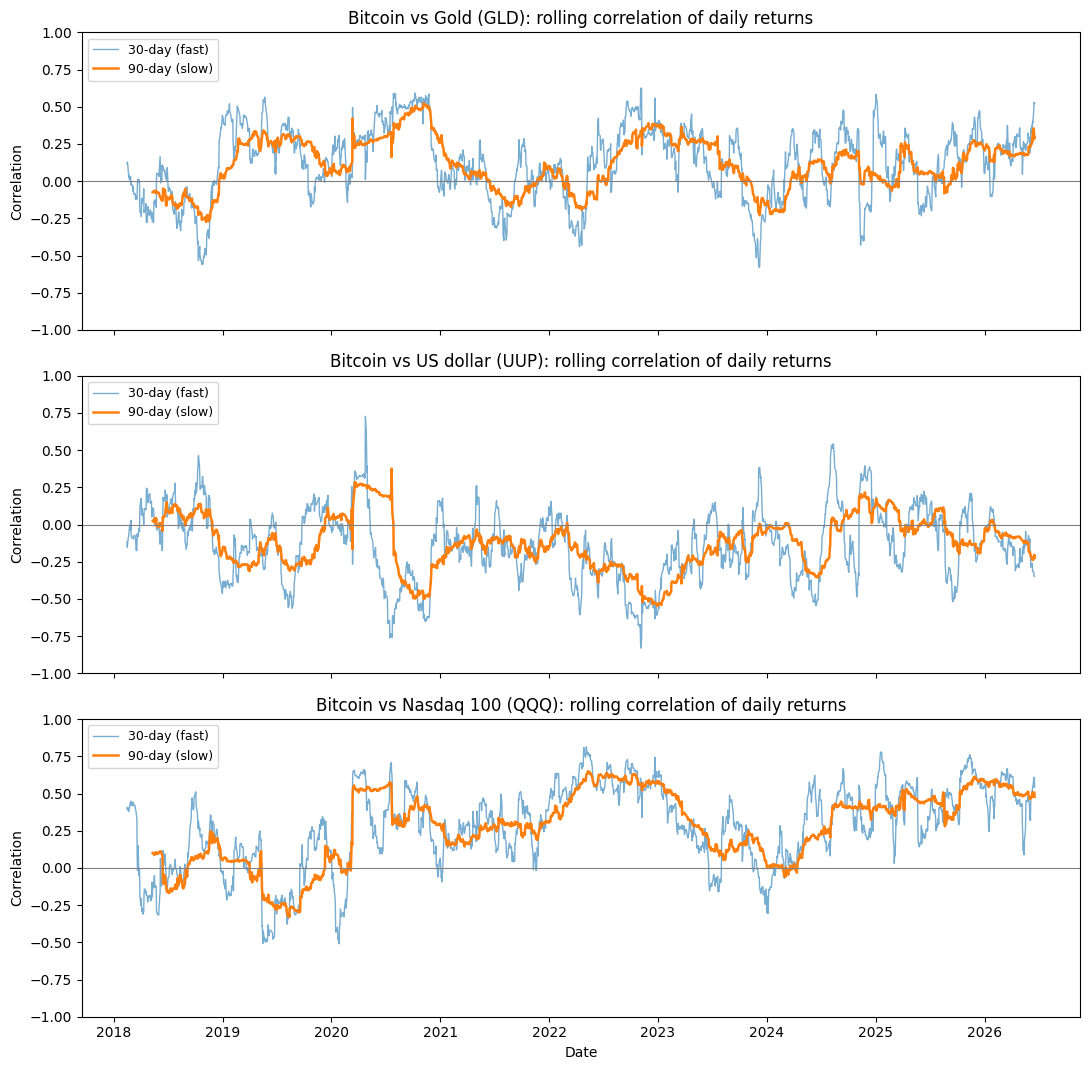

In [5]:
fig, axes = plt.subplots(len(proxy_names), 1, figsize=(11, 3.6 * len(proxy_names)), sharex=True)

for ax, p in zip(axes, proxy_names):
    ax.plot(corr_short.index, corr_short[p], lw=1.0, alpha=0.6, label=f"{SHORT_WIN}-day (fast)")
    ax.plot(corr_long.index,  corr_long[p],  lw=1.8,            label=f"{LONG_WIN}-day (slow)")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Bitcoin vs {p}: rolling correlation of daily returns")
    ax.set_ylabel("Correlation")
    ax.legend(loc="upper left", fontsize=9)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Reading this output

Going label by label:

- Gold: the line spends real time both above and below zero. If Bitcoin were digital gold, this panel would sit steadily positive. It does not, so the data does not support the digital-gold label here.
- Dollar: the line hovers near zero and changes sign repeatedly. A currency alternative would hold a consistent relationship to the dollar. This does not, so the data does not support the currency label.
- Nasdaq: this is the one panel that spends most of its time clearly positive, which is why the risk-on label has more going for it than the other two. But even here the relationship loosens and tightens, so the support is partial, not settled.

## 6. A single view: the three relationships together

Overlaying the three slow (90-day) correlations on one chart makes them easier to compare. You can see which relationship is strongest at each point, and how the ranking changes.

What to look for: whether the lines ever settle into a fixed order. If gold leads during one stretch and the Nasdaq during another, then no single label holds across the period. That instability is the observation this notebook is built around, so it is worth sitting with rather than reading past.

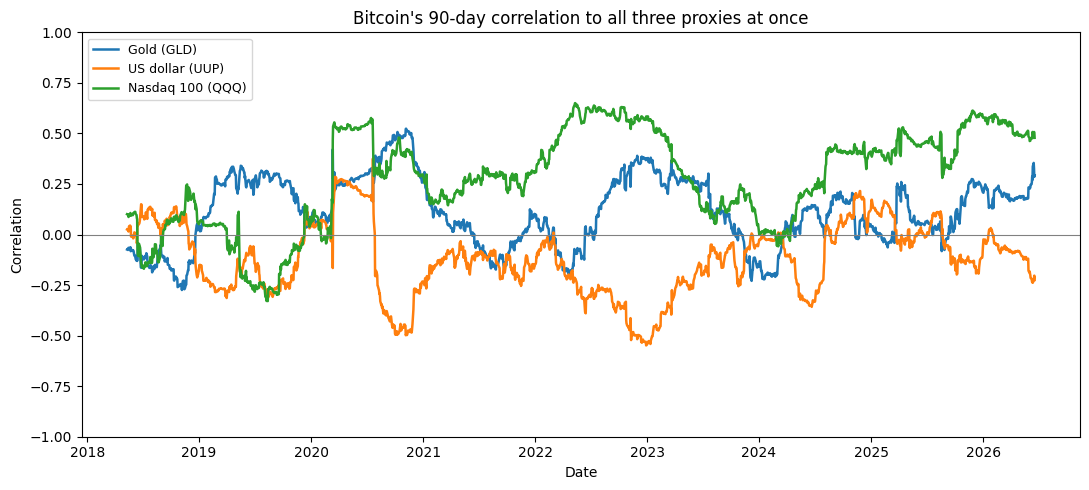

Average 90-day correlation over the whole period:
Gold (GLD)          0.11
US dollar (UUP)    -0.12
Nasdaq 100 (QQQ)    0.28


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for p in proxy_names:
    ax.plot(corr_long.index, corr_long[p], lw=1.8, label=p)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title(f"Bitcoin's {LONG_WIN}-day correlation to all three proxies at once")
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Average correlation per proxy, as a plain summary number
print("Average 90-day correlation over the whole period:")
print(corr_long.mean().round(2).to_string())


### Reading this output

The three lines never settle into a fixed order. Gold leads in some stretches, the Nasdaq in others, and the dollar mostly sits opposite but not always. The 90-day averages (0.11 gold, -0.12 dollar, 0.28 Nasdaq) confirm what the panels showed: the Nasdaq link is the strongest of the three, but none of them is strong in absolute terms.

For the thesis, this is the central observation. If Bitcoin had a stable identity as any one of these, that line would dominate the others consistently. Instead the ranking keeps changing, which is what it looks like when an asset has no fixed relationship to the things it is usually compared to.

## 7. Reading the three labels against the rolling correlations

Taking the three labels one at a time, using only what the rolling correlations show:

- Digital gold: the data does not support a steady positive link to gold. The correlation is modest and it moves around, including stretches near zero. A stable safe-haven relationship would not look like this.
- New currency: the data does not support a consistent relationship to the dollar. The correlation is weak and changes sign over time, which is not what a dollar alternative would show.
- Risk-on: the data gives this label the most support of the three, since the Nasdaq correlation is generally the highest, but support is not the same as a settled fact, because that correlation still varies a good deal over time.

None of this resolves into a single answer, and that is the point rather than a gap. The next sections test these same labels more carefully, because plain correlation cannot tell a real relationship apart from two assets reacting to the same third thing.

## 8. Why plain correlation is not enough

Look again at the overlay. Gold and the Nasdaq are often positively correlated with Bitcoin at the same time, while the dollar sits roughly opposite. That is a sign these three proxies are not independent of each other. When the dollar weakens, both risk assets and gold tend to rise. So when Bitcoin looks correlated to gold, plain correlation cannot tell us whether Bitcoin tracks gold itself, or whether Bitcoin and gold are both just reacting to the dollar.

This matters most for the digital-gold label. To separate a real link from a shared reaction, we need two more tools:

1. A regression of Bitcoin on all three proxies at once, so each one's contribution is measured while the others are held fixed.
2. A partial correlation, which measures the Bitcoin-to-gold link after removing the influence of the dollar and the Nasdaq from both sides.

We build the regression first, see why its coefficients are hard to trust, and let that point us to the partial correlation and the R-squared, which are the measures that hold up.

## 9. Rolling regression: a first attempt, and why its coefficients move so much

Here we regress Bitcoin's returns on all three proxy returns together, over a rolling 90-day window. In principle each coefficient tells you Bitcoin's sensitivity to that proxy while the other two are held constant.

In practice there is a problem worth seeing rather than hiding. The three proxies move together, with the dollar close to a mirror of the Nasdaq. When the explanatory variables are themselves correlated, the regression cannot split credit cleanly between them, and the individual coefficients swing widely from one window to the next, sometimes flipping sign. This is called multicollinearity. It does not mean the regression is broken. It means the individual coefficients are not reliable evidence on their own, and it is part of why a simple, static model of Bitcoin's drivers does not hold together.

What to look for: coefficient lines that jump around and trade places. Do not read a story into any single line's level. The movement itself is the observation, and it is what pushes us toward the two steadier measures that follow.

In [7]:
import statsmodels.api as sm

REG_WIN = 90   # window for the rolling regression and R-squared

proxy_cols = list(PROXIES.keys())
X_all = returns[proxy_cols]
y_all = returns["Bitcoin"]

# Rolling multivariate OLS. We loop windows explicitly so we can keep both the
# coefficients and the R-squared from each fit. This is clearer than vectorising
# and the data is small enough that speed is not a concern.
betas = []
r2 = []
idx = []
for end in range(REG_WIN, len(returns) + 1):
    sl = slice(end - REG_WIN, end)
    Xw = sm.add_constant(X_all.iloc[sl])
    yw = y_all.iloc[sl]
    fit = sm.OLS(yw, Xw).fit()
    betas.append(fit.params[proxy_cols].values)   # drop the constant, keep proxy betas
    r2.append(fit.rsquared)
    idx.append(returns.index[end - 1])

betas = pd.DataFrame(betas, index=idx, columns=proxy_cols)
r2 = pd.Series(r2, index=idx, name="R-squared")
print("Rolling regression computed over", len(r2), "windows")
betas.describe().round(2)


Rolling regression computed over 2037 windows


,Gold (GLD),US dollar (UUP),Nasdaq 100 (QQQ)
count,2037.00,2037.00,2037.00
mean,0.09,-0.70,0.65
std,0.83,1.38,0.64
min,-3.03,-7.30,-1.63
25%,-0.28,-1.49,0.31
50%,0.14,-0.39,0.71
75%,0.69,0.12,1.12
max,2.10,2.15,1.97


### Reading this output

These coefficients are not usable as evidence, and the summary shows why. The dollar coefficient averages -0.70 but ranges from -7.30 to +2.15. The gold coefficient runs from -3.03 to +2.10. Coefficients that swing across that kind of range from one window to the next are not measuring a stable relationship, they are reacting to the fact that the three proxies move together and the regression cannot tell them apart.

This is the multicollinearity described above, seen in the numbers. The takeaway for the thesis is not any single coefficient value, it is that a straightforward regression of Bitcoin on these macro drivers does not produce stable, trustworthy sensitivities. That instability is itself part of the case that Bitcoin does not behave like a settled asset with known drivers.

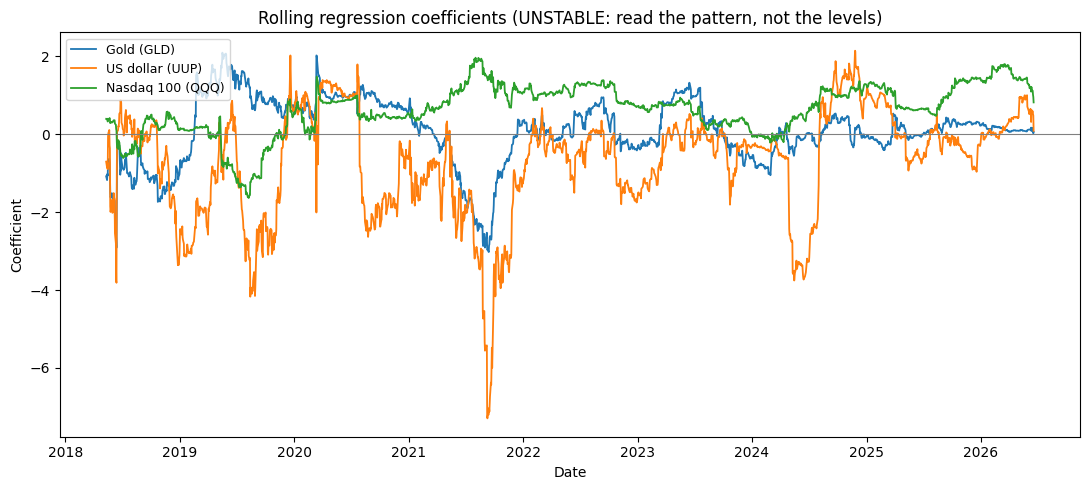

In [8]:
# Plot the rolling coefficients, clearly labelled as unstable
fig, ax = plt.subplots(figsize=(11, 5))
for c in proxy_cols:
    ax.plot(betas.index, betas[c], lw=1.3, label=c)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Rolling regression coefficients (UNSTABLE: read the pattern, not the levels)")
ax.set_ylabel("Coefficient")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### Reading this output

The picture matches the table. The lines cross each other, flip sign, and spike (the dollar coefficient in particular plunges below -7 around 2021). There is no stable level to read off any of them.

This is the visual reason we do not try to say "Bitcoin has a beta of X to gold." The regression cannot support that statement. It is also why the next two measures exist: the R-squared, which stays steady even when the coefficients do not, and the partial correlation, which isolates one relationship at a time.

## 10. Partial correlation: testing the digital-gold link directly

This is the test for the gold label. Partial correlation measures how Bitcoin and gold move together after removing, from both, the part explained by the dollar and the Nasdaq. The steps:

1. Regress Bitcoin on the dollar and the Nasdaq, keep the residual, the part those two do not explain.
2. Regress gold on the dollar and the Nasdaq, keep its residual.
3. Correlate the two residuals.

If the plain Bitcoin-to-gold correlation was mostly both assets riding the dollar, this partial correlation will fall toward zero. If a real, independent link exists, it will survive.

We compute it rolling, for each proxy controlled for the other two, so we can see when a relationship is specific to Bitcoin rather than a shared reaction to something else.

What to look for: compare each partial line to the plain correlation from section 4. Where the partial line sits much closer to zero, the data does not support a direct relationship, the apparent link was mostly the other variables. The gold panel is the one to watch.

In [9]:
def rolling_partial_corr(target, other, controls, window):
    # Partial correlation of `target` and `other`, controlling for `controls`,
    # computed on a rolling window. Returns residual-correlation per window.
    out_idx, out_val = [], []
    C = sm.add_constant(returns[controls])
    for end in range(window, len(returns) + 1):
        sl = slice(end - window, end)
        Cw = C.iloc[sl]
        # residual of target and of other, after removing the controls
        rt = sm.OLS(returns[target].iloc[sl], Cw).fit().resid
        ro = sm.OLS(returns[other].iloc[sl],  Cw).fit().resid
        out_val.append(np.corrcoef(rt, ro)[0, 1])
        out_idx.append(returns.index[end - 1])
    return pd.Series(out_val, index=out_idx)

# For each proxy, control for the OTHER two proxies
partial = {}
for p in proxy_cols:
    controls = [q for q in proxy_cols if q != p]
    partial[p] = rolling_partial_corr("Bitcoin", p, controls, LONG_WIN)
partial = pd.DataFrame(partial)

print("Average partial correlation (controlling for the other two proxies):")
print(partial.mean().round(2).to_string())
print()
print("Compare to average plain correlation from section 4:")
print(corr_long.mean().round(2).to_string())


Average partial correlation (controlling for the other two proxies):
Gold (GLD)          0.04
US dollar (UUP)    -0.05
Nasdaq 100 (QQQ)    0.25

Compare to average plain correlation from section 4:
Gold (GLD)          0.11
US dollar (UUP)    -0.12
Nasdaq 100 (QQQ)    0.28


### Reading this output

This is the clearest result in the notebook, so it is worth reading slowly.

- Gold: the plain correlation of 0.11 falls to 0.04 once the dollar and the Nasdaq are controlled for. Almost the entire apparent gold relationship was not about gold. It was Bitcoin and gold both reacting to the dollar. Strip that shared driver out and what remains is close to nothing. The data does not support the digital-gold label.
- Dollar: -0.12 plain falls to -0.05 controlled. The relationship was weak to begin with and weakens further. The data does not support the currency label.
- Nasdaq: 0.28 plain holds at 0.25 controlled. This is the one relationship that survives the controls almost intact, which means it is a real, direct link rather than a shared reaction to something else. Of the three labels, only risk-on has direct support in the data.

So two labels mostly vanish once you account for the common driver, and one holds. That is the partial correlation earning its place: plain correlation made gold look like a relationship, and this shows it was mostly the dollar wearing a gold costume.

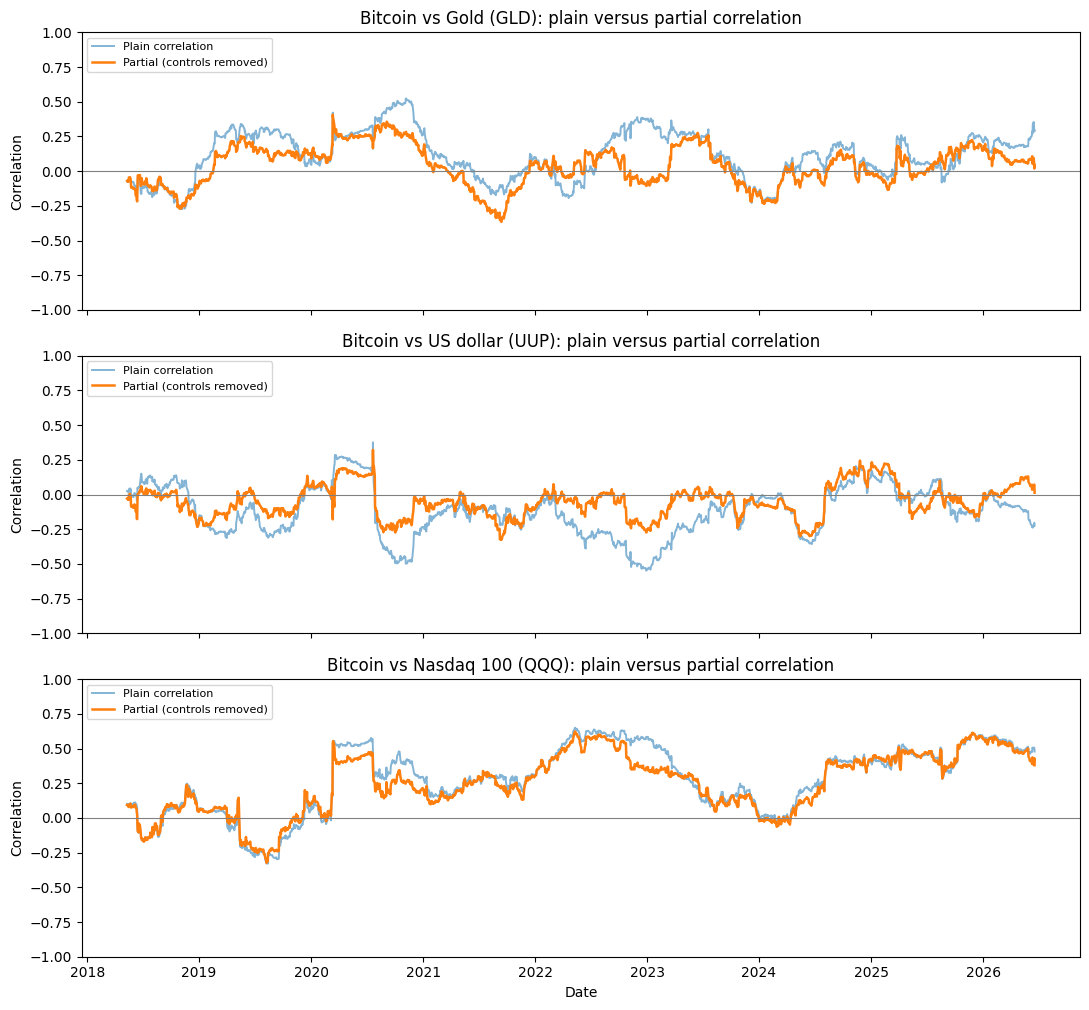

In [10]:
# Plain vs partial, side by side per proxy, so the artifact is visible
fig, axes = plt.subplots(len(proxy_cols), 1, figsize=(11, 3.4 * len(proxy_cols)), sharex=True)
for ax, p in zip(axes, proxy_cols):
    ax.plot(corr_long.index, corr_long[p], lw=1.4, alpha=0.55, label="Plain correlation")
    ax.plot(partial.index,   partial[p],   lw=1.8,             label="Partial (controls removed)")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Bitcoin vs {p}: plain versus partial correlation")
    ax.set_ylabel("Correlation")
    ax.legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Reading this output

The gold panel is the one to watch. The orange partial line sits noticeably closer to zero than the blue plain line through most of the period, which is the visual version of the 0.11 to 0.04 drop. The relationship deflates once its borrowed drivers are removed.

The Nasdaq panel is the opposite: the two lines track each other closely, because that relationship does not depend on the other variables. It stands on its own. The dollar panel sits near zero in both versions. Same conclusion as the averages, now visible across time rather than as a single number.

## 11. How much of Bitcoin does macro explain at all

The most useful line in the notebook is the rolling R-squared from the regression in section 9. Unlike the individual coefficients, the R-squared is steady under multicollinearity, because it measures the joint explanatory power of all three proxies together rather than how credit is split between them.

Read it as: what fraction of Bitcoin's day-to-day movement these three proxies, taken together, account for over the last 90 days. When it is high, Bitcoin is moving with the same forces as stocks, gold, and the dollar. When it falls toward zero, Bitcoin has detached and is moving on forces these proxies cannot see, things like crypto-specific events, flows, and leverage that have no equivalent in this set of assets.

This is where the "shifts between risk-on and something else" idea becomes measurable. The something else is not another proxy. It is the absence of any macro explanation at all.

What to look for: whether the line cycles. Stretches where it climbs, meaning Bitcoin is moving with markets, alternating with stretches where it collapses, meaning Bitcoin is on its own. Line the high stretches up against the partial-correlation chart, and the explaining is usually being done by the Nasdaq, not gold.

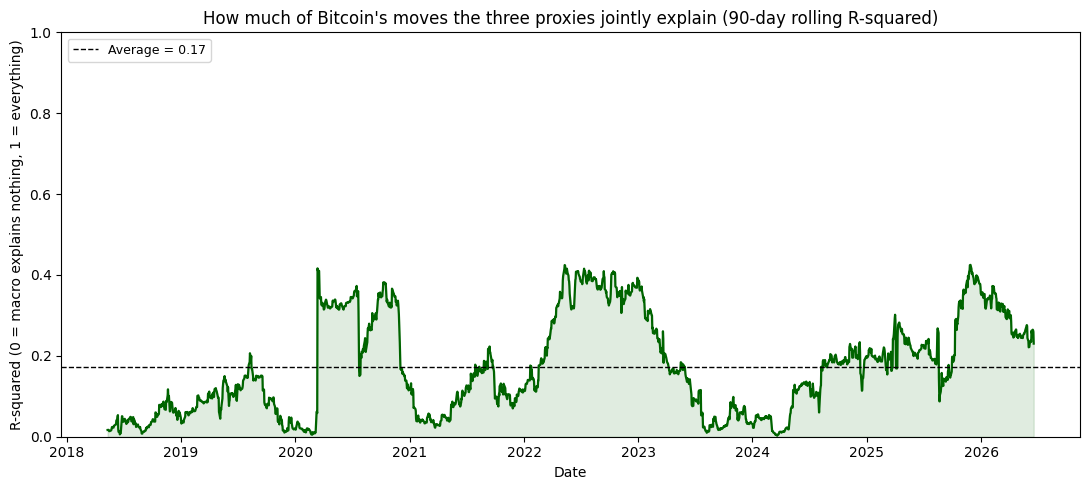

R-squared ranges from 0.00 to 0.43, averaging 0.17.
Low values are periods where Bitcoin moved on forces these macro proxies cannot see.


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(r2.index, r2, lw=1.6, color="darkgreen")
ax.fill_between(r2.index, 0, r2, color="darkgreen", alpha=0.12)
ax.set_ylim(0, 1)
ax.set_title(f"How much of Bitcoin's moves the three proxies jointly explain ({REG_WIN}-day rolling R-squared)")
ax.set_ylabel("R-squared (0 = macro explains nothing, 1 = everything)")
ax.set_xlabel("Date")
# reference line at the full-period average
ax.axhline(r2.mean(), color="black", ls="--", lw=1.0, label=f"Average = {r2.mean():.2f}")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"R-squared ranges from {r2.min():.2f} to {r2.max():.2f}, averaging {r2.mean():.2f}.")
print("Low values are periods where Bitcoin moved on forces these macro proxies cannot see.")


### Reading this output

The rolling R-squared runs from 0.00 to 0.43 and averages 0.17. Two things to take from that.

First, the average. Across the whole period these three macro proxies together explain only about 17 percent of Bitcoin's daily movement. The large majority of what Bitcoin does is not explained by stocks, gold, or the dollar at all.

Second, and more important, the cycling. The line climbs toward 0.4 in stretches like 2020 and 2022, then collapses back toward zero in 2018, 2024, and parts of 2026. When it is high, Bitcoin is moving with the macro world and looks risk-on. When it is low, Bitcoin has detached and is being driven by something these proxies cannot see. This is the "risk-on and something else" pattern made measurable. The something else is not a missing proxy we could add. It is the stretches where no macro explanation applies, and they come and go.

For the thesis: even the risk-on label, the one that survived the partial correlation, only applies part of the time. The relationship switches on and off, which is not how an established asset class behaves.

## 12. What the regression and partial correlation show, label by label

Reading the three labels against these steadier measures, again without forcing a single verdict:

- Digital gold: the data does not support it. The small average correlation to gold shrinks further once the dollar and the Nasdaq are controlled for, which means the apparent gold link was mostly a shared reaction to the dollar rather than a relationship to gold itself.
- New currency: the data does not support it. The relationship to the dollar is weak and unstable whether or not the other variables are controlled.
- Risk-on: the data supports this label more than the other two, since the Nasdaq link is the one that survives the controls. But the support is partial, because the rolling R-squared shows that on average these proxies explain only a minority of Bitcoin's movement, and that explanatory power switches on and off over time.

So across three different methods, plain correlation, regression, and partial correlation, the same thing keeps showing up. Two of the labels are not supported by the data, and the one that is holds only some of the time. The next section tests the labels on the specific days they were meant to describe, the stressed ones.

## 13. Testing the labels on the days that matter: market stress

Everything so far measured average, day-to-day co-movement. The digital-gold label, though, was never about average days. It is a claim about the bad days: the expectation that Bitcoin holds its value, or rises, when other assets are falling. That is a claim about behaviour during stress, not on a typical Tuesday.

So we test it on exactly those days. We find the worst days for the stock market, the bottom 5 percent of Nasdaq return days, and look at what Bitcoin did on them, next to what gold did. A safe haven holds up or gains while stocks fall. If Bitcoin falls with stocks on those days, the data does not support the digital-gold label on the days it was meant to cover.

We test the matching question for the risk-on label using the best 5 percent of Nasdaq days. A risk-on asset should capture the upside. The combination is what matters. An asset that falls with stocks on the worst days but does not rise with them on the best days is taking the losses without the gains.

What to look for: Bitcoin's behaviour on the worst days next to gold's, and Bitcoin's sensitivity to the Nasdaq on the worst days next to its sensitivity on the best days.

In [12]:
# Define stressed and rallying days by the Nasdaq proxy's own return distribution
qqq_ret = returns["Nasdaq 100 (QQQ)"]

lo_cut = qqq_ret.quantile(0.05)   # bottom 5%: market stress
hi_cut = qqq_ret.quantile(0.95)   # top 5%: market rallies

worst_days = returns[qqq_ret <= lo_cut]
best_days  = returns[qqq_ret >= hi_cut]

print(f"Worst-day threshold: QQQ <= {lo_cut*100:.2f}%   ({len(worst_days)} days)")
print(f"Best-day  threshold: QQQ >= {hi_cut*100:.2f}%   ({len(best_days)} days)")


Worst-day threshold: QQQ <= -2.43%   (107 days)
Best-day  threshold: QQQ >= 2.22%   (107 days)


In [13]:
# Average return of each asset on stressed days and on rally days.
# A safe haven should be flat or positive on worst days. A risk-on asset
# should be strongly positive on best days.

def avg_on(days, col):
    return days[col].mean() * 100   # in percent

rows = []
for col in ["Bitcoin", "Nasdaq 100 (QQQ)", "Gold (GLD)"]:
    rows.append({
        "Asset": col,
        "Avg return, worst QQQ days (%)": round(avg_on(worst_days, col), 2),
        "Avg return, best QQQ days (%)":  round(avg_on(best_days,  col), 2),
    })

conditional = pd.DataFrame(rows).set_index("Asset")
conditional


,"Avg return, worst QQQ days (%)","Avg return, best QQQ days (%)"
Asset,,
Bitcoin,-2.98,2.35
Nasdaq 100 (QQQ),-3.54,3.32
Gold (GLD),-0.14,0.27


### Reading this output

This tests the digital-gold label on the days it was actually meant to describe, the market's worst.

On the 107 worst Nasdaq days, gold returned -0.14 percent on average. Essentially flat while the Nasdaq fell 3.54 percent. That is what a safe haven looks like: it ignores the stress. Bitcoin on those same days returned -2.98 percent. It fell, heavily, right alongside the market. The data does not support Bitcoin acting as a safe haven on the days a safe haven would matter.

On the best days, all three are positive, with Bitcoin up 2.35 percent against the Nasdaq's 3.32. Bitcoin participates in the upside, but by less than the index. Hold that thought for the next cell, because the upside and downside participation are not symmetric, and that asymmetry is the point.

In [14]:
# Downside vs upside capture: Bitcoin's sensitivity (slope) to the Nasdaq,
# measured separately on stressed days and on rally days. If the downside
# slope is steeper than the upside slope, Bitcoin amplifies losses more than gains.

def slope_on(days, col, ref="Nasdaq 100 (QQQ)"):
    x = days[ref].values
    y = days[col].values
    return np.polyfit(x, y, 1)[0]   # slope of col on the Nasdaq within these days

btc_down = slope_on(worst_days, "Bitcoin")
btc_up   = slope_on(best_days,  "Bitcoin")
gld_down = slope_on(worst_days, "Gold (GLD)")
gld_up   = slope_on(best_days,  "Gold (GLD)")

print("Sensitivity to the Nasdaq, measured in the tails:")
print(f"  Bitcoin, worst days (downside): {btc_down:.2f}")
print(f"  Bitcoin, best days  (upside):   {btc_up:.2f}")
print(f"  Gold,    worst days (downside): {gld_down:.2f}")
print(f"  Gold,    best days  (upside):   {gld_up:.2f}")
print()
if btc_down > btc_up:
    print(f"Bitcoin amplifies the Nasdaq MORE on the way down ({btc_down:.2f}) than up ({btc_up:.2f}):")
    print("it captures more of the losses than the gains, the opposite of what you want.")
else:
    print(f"Bitcoin's upside sensitivity ({btc_up:.2f}) exceeds its downside ({btc_down:.2f}).")


Sensitivity to the Nasdaq, measured in the tails:
  Bitcoin, worst days (downside): 2.12
  Bitcoin, best days  (upside):   0.85
  Gold,    worst days (downside): 0.26
  Gold,    best days  (upside):   0.26

Bitcoin amplifies the Nasdaq MORE on the way down (2.12) than up (0.85):
it captures more of the losses than the gains, the opposite of what you want.


### Reading this output

This is the sharpest single result on the risk-on label.

Gold's sensitivity to the Nasdaq is 0.26 on the worst days and 0.26 on the best days. Identical. Gold does not care which way the market is going, which is exactly why it diversifies.

Bitcoin is the opposite. Its sensitivity to the Nasdaq is 2.12 on the worst days but only 0.85 on the best days. It moves with the market two and a half times more strongly when stocks are falling than when they are rising. In plain terms, Bitcoin shows up for the losses and is half-absent for the gains.

For the thesis this is the catch in the risk-on label. Even though risk-on was the one label that survived every earlier test, the exposure it gives you is lopsided in the wrong direction. It also explains the lived experience of a period like 2026, where risk assets rallied and Bitcoin did not keep pace, despite having fallen with them when they dropped. An asset that tracks the downside more than the upside is not a clean risk-on holding, and it is not a diversifier either. It is its own thing, which is where this whole notebook keeps landing.

## 14. What the stressed-day test shows, and what it leaves open

This is the evidence the average-day correlations could not give, because it looks at the exact days the labels were meant to describe.

On the digital-gold label, gold's behaviour on the market's worst days is the benchmark for a safe haven. If Bitcoin falls on those days while gold stays flat, the data does not support Bitcoin acting as a safe haven when one is needed. On these days it does close to the opposite.

On the risk-on label, the capture numbers show whether Bitcoin is even a clean version of that. A clean risk-on asset captures the upside in exchange for the downside. If Bitcoin's sensitivity to the market is higher when stocks fall than when they rise, the exposure is lopsided: fuller on the bad days, lighter on the good ones. That also fits stretches where risk assets rallied and Bitcoin did not keep pace, even after falling with them earlier.

Pulling the whole notebook together, the same pattern holds across every method used, plain correlation, regression, partial correlation, and the stressed-day test:

- The data does not support the digital-gold label. The gold correlation does not survive controlling for the dollar, and on stressed days Bitcoin falls rather than shelters.
- The data does not support the currency label. The dollar relationship is weak and unstable either way.
- The data supports the risk-on label only in part. Macro explains a minority of Bitcoin's moves on average, that explanation cycles on and off, and even the risk exposure is lopsided toward the downside.

What it does not do is hand back a single answer to what Bitcoin is, and that is the finding rather than a shortfall. Across decades of data we can describe what a stock or a bond or gold is, because their relationships hold still long enough to model. Bitcoin's do not, at least not yet, and not with the tools that work on established asset classes. That is not a verdict for or against Bitcoin. It is a measurement of how new and unsettled it still is, and a reason to be careful about treating it as something we already understand.